In [1]:
!pip install networkx matplotlib pandas

In [2]:
def decrypt_caesar(text, shift):
    result = ""
    for char in text:
        if char.isalpha():
            shift_base = 65 if char.isupper() else 97
            result += chr((ord(char) - shift_base - shift) % 26 + shift_base)
        else:
            result += char
    return result

# Example encrypted drugs
encrypted_prescription = ["Sdudfhwdpro", "Lehsurihq", "Dvsulq"]

# Assume shift = 3 (you can make dynamic later)
decrypted_drugs = [decrypt_caesar(drug, 3) for drug in encrypted_prescription]

print("Decrypted Drugs:", decrypted_drugs)

Decrypted Drugs: ['Paracetamol', 'Ibeprofen', 'Asprin']


In [3]:
# Sample drug interaction database
drug_interactions = {
    ("Paracetamol", "Ibuprofen"): "Moderate",
    ("Aspirin", "Ibuprofen"): "High",
    ("Aspirin", "Paracetamol"): "Low"
}

In [4]:
from itertools import combinations

def check_interactions(drugs):
    interactions_found = []

    for d1, d2 in combinations(drugs, 2):
        pair = (d1, d2)
        pair_rev = (d2, d1)

        if pair in drug_interactions:
            interactions_found.append((d1, d2, drug_interactions[pair]))
        elif pair_rev in drug_interactions:
            interactions_found.append((d1, d2, drug_interactions[pair_rev]))

    return interactions_found

interactions = check_interactions(decrypted_drugs)

print("Detected Interactions:")
for i in interactions:
    print(i)

Detected Interactions:


In [7]:
from itertools import combinations
from difflib import get_close_matches

# Known valid drug names (from your database)
valid_drugs = ["Paracetamol", "Ibuprofen", "Aspirin"]

# Fix spelling using fuzzy matching
def correct_drug_name(drug):
    match = get_close_matches(drug, valid_drugs, n=1, cutoff=0.6)
    return match[0] if match else drug

def check_interactions(drugs):
    interactions_found = []

    # Normalize + correct names
    corrected_drugs = [correct_drug_name(d.strip().capitalize()) for d in drugs]

    print("Corrected Drugs:", corrected_drugs)

    for d1, d2 in combinations(corrected_drugs, 2):
        pair = (d1, d2)
        pair_rev = (d2, d1)

        if pair in drug_interactions:
            interactions_found.append((d1, d2, drug_interactions[pair]))
        elif pair_rev in drug_interactions:
            interactions_found.append((d1, d2, drug_interactions[pair_rev]))

    return interactions_found

# Run detection
interactions = check_interactions(decrypted_drugs)

print("\nDetected Interactions:")
if interactions:
    for i in interactions:
        print(f"{i[0]} - {i[1]} → {i[2]}")
else:
    print("No interactions found ❌")

Corrected Drugs: ['Paracetamol', 'Ibuprofen', 'Aspirin']

Detected Interactions:
Paracetamol - Ibuprofen → Moderate
Paracetamol - Aspirin → Low
Ibuprofen - Aspirin → High


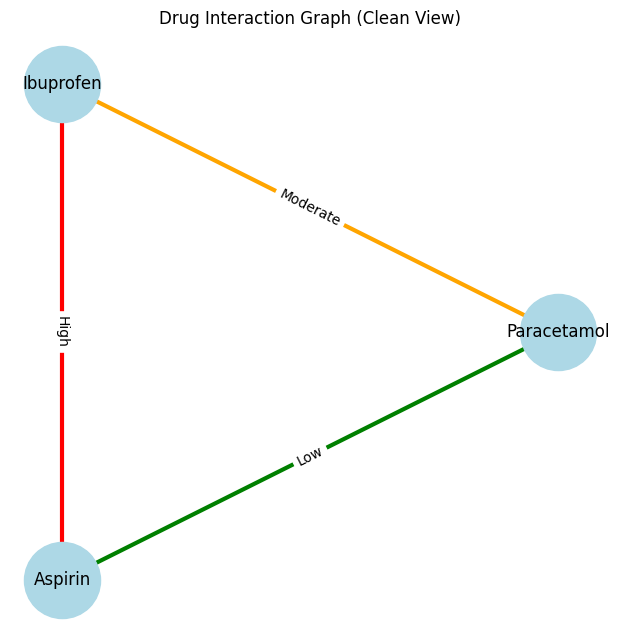

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# Use corrected drugs
corrected_drugs = [correct_drug_name(d.strip().capitalize()) for d in decrypted_drugs]

G = nx.Graph()

# Add nodes
for drug in corrected_drugs:
    G.add_node(drug)

# Add edges + colors
edge_colors = []
for d1, d2, severity in interactions:
    G.add_edge(d1, d2, label=severity)

    if severity == "High":
        edge_colors.append('red')
    elif severity == "Moderate":
        edge_colors.append('orange')
    else:
        edge_colors.append('green')

# ✅ Better layout
pos = nx.circular_layout(G)   # <-- KEY FIX (instead of spring_layout)

plt.figure(figsize=(6,6))     # square layout

# Draw graph
nx.draw(G, pos,
        with_labels=True,
        node_size=3000,
        node_color='lightblue',
        edge_color=edge_colors,
        width=3,
        font_size=12)

# Edge labels
edge_labels = {(d1, d2): severity for d1, d2, severity in interactions}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

plt.title("Drug Interaction Graph (Clean View)")
plt.axis('off')  # removes background junk
plt.show()

🔐 Encrypted Prescription: ['Sdudfhwdpro', 'Lehsurihq', 'Dvslulq']

🔓 Decrypted Drugs: ['Paracetamol', 'Ibeprofen', 'Aspirin']

✅ Corrected Drugs: ['Paracetamol', 'Ibuprofen', 'Aspirin']
Corrected Drugs: ['Paracetamol', 'Ibuprofen', 'Aspirin']

📊 Drug Interactions:
Paracetamol + Ibuprofen → Moderate
Paracetamol + Aspirin → Low
Ibuprofen + Aspirin → High

🚨 HIGH RISK ALERTS:
Ibuprofen + Aspirin → HIGH RISK ⚠️


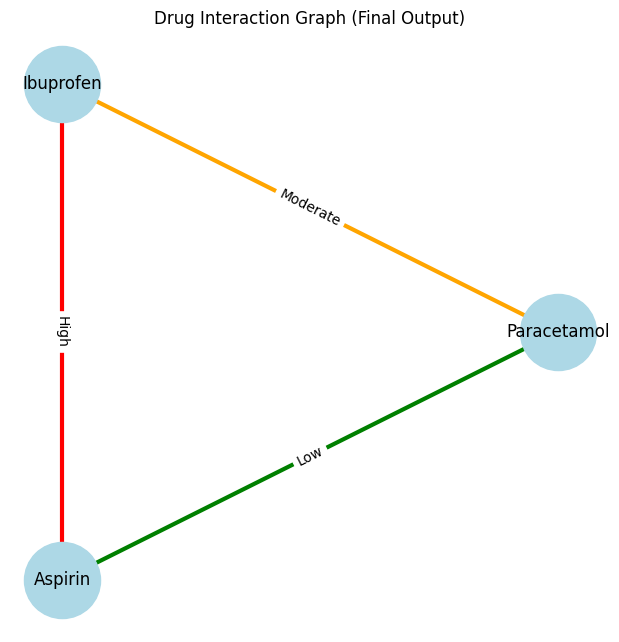

In [11]:
# ===============================
# 💊 PHARMACEUTICAL INTERACTION ENGINE
# ===============================

# 🔐 Input (Encrypted Prescription)
encrypted_input = ["Sdudfhwdpro", "Lehsurihq", "Dvslulq"]
shift = 3

print("🔐 Encrypted Prescription:", encrypted_input)

# -------------------------------
# 🔓 Step 1: Decrypt
# -------------------------------
decrypted = [decrypt_caesar(d, shift) for d in encrypted_input]
print("\n🔓 Decrypted Drugs:", decrypted)

# -------------------------------
# ✅ Step 2: Correct Drug Names
# -------------------------------
corrected = [correct_drug_name(d.strip().capitalize()) for d in decrypted]
print("\n✅ Corrected Drugs:", corrected)

# -------------------------------
# ⚠️ Step 3: Detect Interactions
# -------------------------------
interactions = check_interactions(corrected)

print("\n📊 Drug Interactions:")
for d1, d2, severity in interactions:
    print(f"{d1} + {d2} → {severity}")

# -------------------------------
# 🚨 Step 4: High Risk Detection
# -------------------------------
print("\n🚨 HIGH RISK ALERTS:")
high_risk = [i for i in interactions if i[2] == "High"]

if high_risk:
    for case in high_risk:
        print(f"{case[0]} + {case[1]} → HIGH RISK ⚠️")
else:
    print("No high-risk interactions")

# -------------------------------
# 🌐 Step 5: Graph Visualization
# -------------------------------
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
edge_colors = []

for drug in corrected:
    G.add_node(drug)

for d1, d2, severity in interactions:
    G.add_edge(d1, d2)

    if severity == "High":
        edge_colors.append('red')
    elif severity == "Moderate":
        edge_colors.append('orange')
    else:
        edge_colors.append('green')

pos = nx.circular_layout(G)

plt.figure(figsize=(6,6))

nx.draw(G, pos,
        with_labels=True,
        node_size=3000,
        node_color='lightblue',
        edge_color=edge_colors,
        width=3,
        font_size=12)

edge_labels = {(d1, d2): severity for d1, d2, severity in interactions}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Drug Interaction Graph (Final Output)")
plt.axis('off')
plt.show()

In [12]:
# ===============================
# 💊 PHARMACEUTICAL INTERACTION ENGINE
# ===============================

In [13]:
# 🔐 Input
# 🔓 Decryption
# ✅ Correction
# ⚠️ Interaction Detection
# 🚨 Risk Analysis
# 🌐 Visualization

In [15]:
encrypted_input = ["Sdudfhwdpro", "Lehsurihq", "Dvslulq"]
shift = 3

In [16]:
print("\n===============================")
print("💊 PHARMACEUTICAL ENGINE RESULT")
print("===============================")

print("\n✅ Final Drugs:", corrected)

print("\n📊 Total Interactions:", len(interactions))

high_risk = [i for i in interactions if i[2] == "High"]

if high_risk:
    print("\n🚨 CRITICAL WARNING:")
    for case in high_risk:
        print(f"{case[0]} + {case[1]} → HIGH RISK")
else:
    print("\n✅ No high-risk interactions")

print("\n✔ Analysis Complete")


💊 PHARMACEUTICAL ENGINE RESULT

✅ Final Drugs: ['Paracetamol', 'Ibuprofen', 'Aspirin']

📊 Total Interactions: 3

🚨 CRITICAL WARNING:
Ibuprofen + Aspirin → HIGH RISK

✔ Analysis Complete
